In [2]:

#  1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc





In [4]:
#  2. Load Dataset

data = pd.read_csv("C:/Users/lenovo/OneDrive/Documents/project2-ml-classifier/data/BreastCancer.csv")

print("Dataset Shape:", data.shape)
print("Columns:", data.columns)




Dataset Shape: (699, 11)
Columns: Index(['Id', 'Cl.thickness', 'Cell.size', 'Cell.shape', 'Marg.adhesion',
       'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli',
       'Mitoses', 'Class'],
      dtype='object')


In [5]:

# 3. Separate Features & Target

# Target variable (already 0 and 1)
y = data['Class']

# Features
X = data.drop(columns=['Class'])

print("Unique target values:", y.unique())




Unique target values: [0 1]


In [6]:
#  4. Data Cleaning

# Replace '?' with NaN
X = X.replace('?', np.nan)

# Convert all columns to numeric
X = X.apply(pd.to_numeric)

# Fill missing values with column mean
X = X.fillna(X.mean())

print("Remaining NaN in X:", X.isnull().sum().sum())



Remaining NaN in X: 0


In [7]:
#  5. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (559, 10)
Test shape: (140, 10)


In [8]:
#  6. Feature Scaling
# 
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 7. Train Random Forest Model

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)



In [9]:
#  8. Model Evaluation

accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", accuracy)



Random Forest Accuracy: 0.9857142857142858


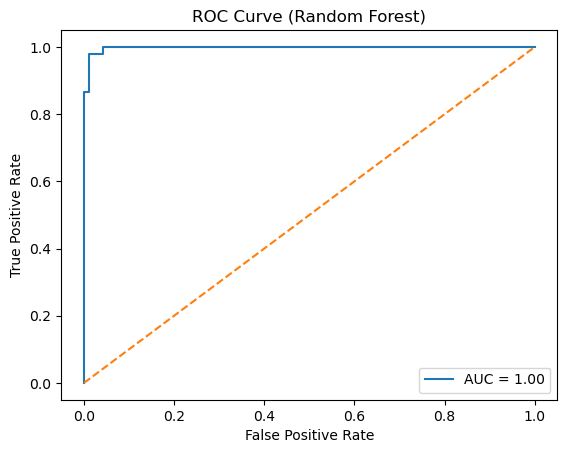

AUC Score: 0.9978947368421053


In [10]:
# 9. ROC Curve
# 
rf_probs = rf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, rf_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Random Forest)")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)



In [11]:
# 10. Feature Importance

importances = rf.feature_importances_

feature_names = X.columns

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Top Features:\n", feat_df.head())



Top Features:
         Feature  Importance
2     Cell.size    0.226109
3    Cell.shape    0.179427
6   Bare.nuclei    0.164892
7   Bl.cromatin    0.160813
5  Epith.c.size    0.086073


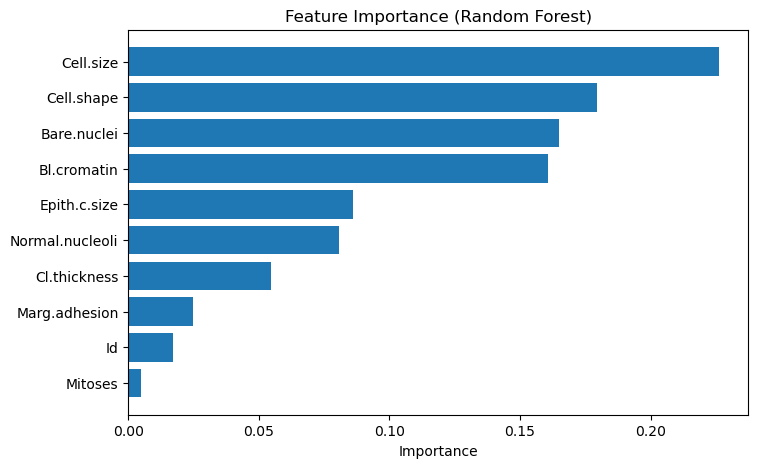

In [12]:
# Plot Feature Importance
plt.figure(figsize=(8,5))
plt.barh(feat_df['Feature'], feat_df['Importance'])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")

plt.show()